# Import

In [1]:
from parcels import (
        FieldSet,
        JITParticle,
        ScipyParticle,
        ParticleSet,
        AdvectionRK4,
        AdvectionRK4_3D,
        StatusCode,
)
import parcels

import datetime as dt
from datetime import datetime, timedelta

import dask

import numpy as np
from numpy.random import uniform, randint

from pathlib import Path
import geopandas as gpd
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import cmocean

import xarray as xr
from glob import glob
import cartopy
import cartopy.crs as ccrs
from time import time
import warnings
import shapely
import itertools

warnings.simplefilter("ignore")

In [2]:
from itertools import chain

In [3]:
release_year=2020
years = range(release_year, release_year + 1)
first_release_date_str=20200101
last_loaded_date_str=20200115

In [4]:
# establish folder paths
save_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/", str(release_year))
path_orig_files = Path("/gxfs_work/geomar/smomw400/bsh_operationalmodel_data")
path_sigma_files = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/sigma")
path_static_files = Path("/gxfs_work/geomar/smomw122/bsh_operationalmodel_data")
path_static_fine = Path(path_static_files, "static_file_fine")
path_static_coarse = Path(path_static_files, "static_file_coarse")

# get static file paths
lonlat_file_fine = Path(path_static_fine, "lonlat_file_fine.nc")
lonlat_file_coarse = Path(path_static_coarse, "lonlat_file_coarse.nc")

sigma_file_fine = Path(path_sigma_files, "sigma_fine.nc")
sigma_file_coarse = Path(path_sigma_files, "sigma_coarse.nc")

In [5]:
# Get all the subfolders for the requested years
current_subfolder_fine = list(map(lambda year: "c_file_fine_" + str(year), years))
current_subfolder_coarse = list(map(lambda year: "c_file_coarse_" + str(year), years))

In [6]:
# Get filenames from the subfolder while filtering them for the timeframe 
def get_file_list(subfolder_list: list, path: Path, release_year=release_year, first_date:str=first_release_date_str, last_date:str=last_loaded_date_str):
        files_list = list(
                chain.from_iterable(
                        sorted(path.glob(f"{subfolder}/*")) 
                        for subfolder in subfolder_list))
        # Get the position of the date in the file name 
        a = files_list[0].name.find(str(release_year))
        b = a + 8
        # filter list for dates, between the start and end of the timeframe
        return list(filter(
                lambda file: int(first_date) <= int(file.name[a:b]) <= int(last_date),
                files_list
        ))

In [7]:
# get file list paths
current_files_fine = get_file_list(current_subfolder_fine, path_orig_files)
current_files_coarse = get_file_list(current_subfolder_coarse, path_orig_files)
print(
        "Number of files per list:", len(current_files_coarse),
        "\nlast loaded file:", current_files_coarse[-1].name,
)

Number of files per list: 60 
last loaded file: c_file_coarse_2020011518_000_006.nc


In [72]:
fine = xr.open_mfdataset(current_files_fine)
if not "flon" in globals(): 
        flon = fine.lon > 9

fine = fine.where(flon, drop=True)[["uvel", "vvel"]]
fine = fine.where(((fine.lon > 10.5) | (fine.lat > 54)), np.nan)
if not "fln" in globals(): 
        fln = fine.isel(time=0).layer_number.where(fine.isel(time=0).uvel.notnull()).max('layer_number').drop("time").astype(int).compute()
try:
        fine_bottom = fine.sel(layer_number=fln)
except:
        print("no")
        fine_bottom = fine.sel(layer_number=fln, method="bfill")
        fln = fine.layer_number.drop("layer_number")
fine_surface = fine.isel(layer_number=1)


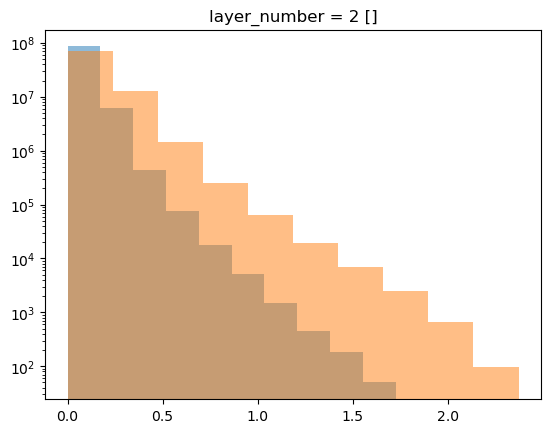

In [73]:
((fine_bottom.uvel**2 + fine_bottom.vvel**2)**.5).plot.hist(yscale="log", alpha=.5)
((fine_surface.uvel**2 + fine_surface.vvel**2)**.5).plot.hist(yscale="log", alpha=.5)
plt.show()

In [69]:
coarse = xr.open_mfdataset(current_files_coarse)
if not "clon" in globals(): 
        clon = coarse.lon > 9

coarse = coarse.where(clon, drop=True)[["uvel", "vvel"]]
coarse = coarse.where(((coarse.lon > 10.5) | (coarse.lat > 54)), np.nan)
if not "cln" in globals(): 
        cln = coarse.isel(time=0).layer_number.where(coarse.isel(time=0).uvel.notnull()).max('layer_number').drop("time").astype(int).compute()
try:
        coarse_bottom = coarse.sel(layer_number=cln)
except:
        print("no")
        coarse_bottom = coarse.sel(layer_number=cln, method="bfill")
        cln = coarse_bottom.layer_number.drop("layer_number")
coarse_surface = coarse.isel(layer_number=1)

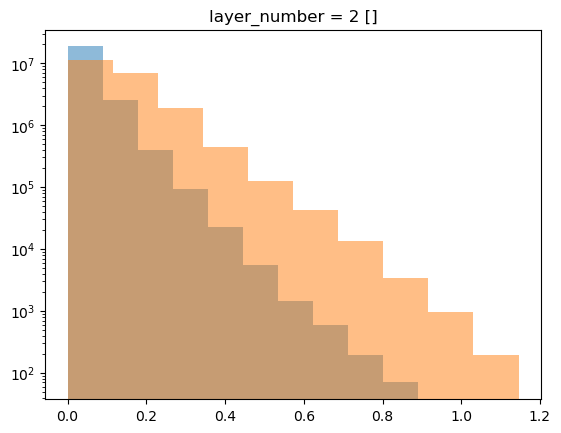

In [71]:
((coarse_bottom.uvel**2 + coarse_bottom.vvel**2)**.5).plot.hist(yscale="log", alpha=.5)
((coarse_surface.uvel**2 + coarse_surface.vvel**2)**.5).plot.hist(yscale="log", alpha=.5)
plt.show()

# Set Parameters

In [4]:
# zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2021/TEST_Fucus_BSH_20210101-20210129_dt60min_N43600_seed123.zarr")
zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2022/Fucus_BSH_20220101-20220625_dt60min_N453440_seed123.zarr")
ds_trajectories = xr.open_zarr(zarr_path)#.compute()
ds_trajectories.nbytes/1e9

96.205479136

In [5]:
ds_trajectories

<xarray.Dataset> Size: 96GB
Dimensions:     (trajectory: 453440, obs: 5304)
Coordinates:
  * obs         (obs) int32 21kB 0 1 2 3 4 5 6 ... 5298 5299 5300 5301 5302 5303
  * trajectory  (trajectory) int64 4MB 0 1 2 3 4 ... 453436 453437 453438 453439
Data variables:
    age_sec     (trajectory, obs) float32 10GB dask.array<chunksize=(453440, 24), meta=np.ndarray>
    cell_ID     (trajectory, obs) float32 10GB dask.array<chunksize=(453440, 24), meta=np.ndarray>
    lat         (trajectory, obs) float64 19GB dask.array<chunksize=(453440, 24), meta=np.ndarray>
    lon         (trajectory, obs) float64 19GB dask.array<chunksize=(453440, 24), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 19GB dask.array<chunksize=(453440, 24), meta=np.ndarray>
    z           (trajectory, obs) float64 19GB dask.array<chunksize=(453440, 24), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_SIGMABSHaging_kernel
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [3]:
try: ds_trajectories = ds_trajectories.rename(dict(CellID="cell_ID"))
except: ""
list_cell_ID = ds_trajectories.cell_ID.isel(obs=0).astype(int)

In [4]:
release_area_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/Fucus_location_shp")
gdf_release_area = gpd.read_file(Path(release_area_path, "REDLIST_SIS_Macrophytes.geojson"))
gdf_release_area = gdf_release_area.loc[(gdf_release_area.F_vesiculo != 0).values, ["geometry", "CELLCODE"]]

subbasins_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/HELCOM_subbasins_2022_level2")
gdf_subbasins_area = gpd.read_file(Path(subbasins_path, "HELCOM_subbasins_2022_level2.shp"))
gdf_subbasins_area = gdf_subbasins_area.to_crs(crs=ccrs.Geodetic()).rename(dict(level_2="subbasin"), axis=1)

In [5]:
subbasins_simple = gdf_subbasins_area.set_index("subbasin").geometry.buffer(0.2).buffer(-0.2).exterior
release_centroid = gpd.GeoDataFrame(gdf_release_area.CELLCODE, geometry=gdf_release_area.geometry.centroid)
gdf_release_area = gpd.sjoin_nearest(
        left_df=release_centroid, 
        right_df=gdf_subbasins_area, 
        how="left", 
        rsuffix="basin_",
)[["CELLCODE", "subbasin", "geometry"]]

In [6]:
def calc_dist(ds):
        ds = ds[["lon", "lat"]]
        dist = 111e3 * (
                ((ds - ds.isel(obs=0, drop=True)) ** 2).to_array() 
                * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
        ).sum(dim="variable")**0.5
        return dist.where(ds.lon.notnull()).rename("dist")

In [7]:
try: ds_trajectories.lat.isel(trajectory=0).compute()
except: ds_trajectories = ds_trajectories.isel(obs=slice(2112))

In [8]:
earth_radius = 6271.0
degrees_to_radians = np.pi / 180.0
radians_to_degrees = 180.0 / np.pi

def dlat_to_dkm(dlat):
        return dlat * earth_radius * degrees_to_radians
def dlon_to_dkm(latitude, dlon):
        r = earth_radius * np.cos(np.multiply(latitude, degrees_to_radians))
        return dlon / r * degrees_to_radians
def latlon_dist_to_km(ds):
        dlat = ds.lat - ds.lat.isel(obs=0, drop=True)
        return ((dlat_to_dkm(dlat)**2 + dlon_to_dkm(ds.lat + dlat/2, ds.lon - ds.lon.isel(obs=0, drop=True))**2)**.5).rename("dist")

In [9]:
ds_trajectories = ds_trajectories.assign(dict(
        distance=latlon_dist_to_km(ds_trajectories),
        subbasin=("trajectory", gdf_release_area.loc[list_cell_ID].subbasin.values),
        # cell_code=("trajectory", cell_codes),
))

In [10]:
last_valid_obs = ds_trajectories.obs.where(ds_trajectories.lon.notnull()).max('obs').astype(int).compute()
last_step = ds_trajectories.isel(obs=last_valid_obs).compute()

ds_trajectories = ds_trajectories.where(last_step.distance.drop("obs") > 10, drop=True)

In [11]:
if len(np.unique(ds_trajectories.isel(obs=0).z.compute())) > 1:
        ds_traj = ds_trajectories.isel(obs=0).groupby("z")
        ds_traj_0 = ds_trajectories.sel(trajectory=ds_traj[0].trajectory.values)
        ds_traj_1 = ds_trajectories.sel(trajectory=ds_traj[1].trajectory.values)

In [12]:
lon_min, lon_max = (5,32)
lat_min, lat_max = (53,66)
central_longitude = np.mean((lon_min, lon_max))
central_latitude = np.mean((lat_min, lat_max))

In [13]:
from xhistogram.xarray import histogram as xhist

In [17]:
def calc_hist_0(ds, lon_bins, lat_bins, dims=["trajectory"]):
        return xhist(
                ds.lon, ds.lat,
                bins=[lon_bins, lat_bins],
                dim=dims,
        ).rename(dict(lon_bin="lon",lat_bin="lat"))

In [18]:
def calc_hist_1(ds, lon_bins, lat_bins, dims=["trajectory"], weights=None, ):
        return (
                xhist(
                        ds.lon, ds.lat,
                        bins=[lon_bins, lat_bins],
                        dim=dims,
                        weights=weights,
                ).rename(dict(lon_bin="lon",lat_bin="lat")) 
                / calc_hist_0(ds, lon_bins, lat_bins, dims)
        )

In [16]:
n_bins = 120
ds_plot_traj_0_count = ds_traj_0.groupby("subbasin").apply(
        lambda ds: 
        np.log10(
                calc_hist_0(
                        ds.unstack(),
                        np.linspace(lon_min, lon_max, n_bins),
                        np.linspace(lat_min, lat_max, n_bins),
                        dims=["trajectory"],
                )
        )
).compute()

In [19]:
n_bins = 120
ds_plot_traj_1_count = ds_traj_1.groupby("subbasin").apply(
        lambda ds: 
        np.log10(
                calc_hist_0(
                        ds.unstack(),
                        np.linspace(lon_min, lon_max, n_bins),
                        np.linspace(lat_min, lat_max, n_bins),
                        dims=["trajectory", "obs"],
                )
        )
).compute()

In [20]:
n_bins = 120
ds_plot_traj_0_age = ds_traj_0.groupby("subbasin").apply(
        lambda ds: 
        calc_hist_1(
                ds,
                np.linspace(lon_min, lon_max, n_bins),
                np.linspace(lat_min, lat_max, n_bins),
                dims=["trajectory", "obs"],
                weights=ds.obs,
        )
).compute()

In [21]:
n_bins = 120
ds_plot_traj_1_age = ds_traj_1.groupby("subbasin").apply(
        lambda ds: 
        calc_hist_1(
                ds,
                np.linspace(lon_min, lon_max, n_bins),
                np.linspace(lat_min, lat_max, n_bins),
                dims=["trajectory", "obs"],
                weights=ds.obs,
        )
).compute()

# Maps

## Heatmap

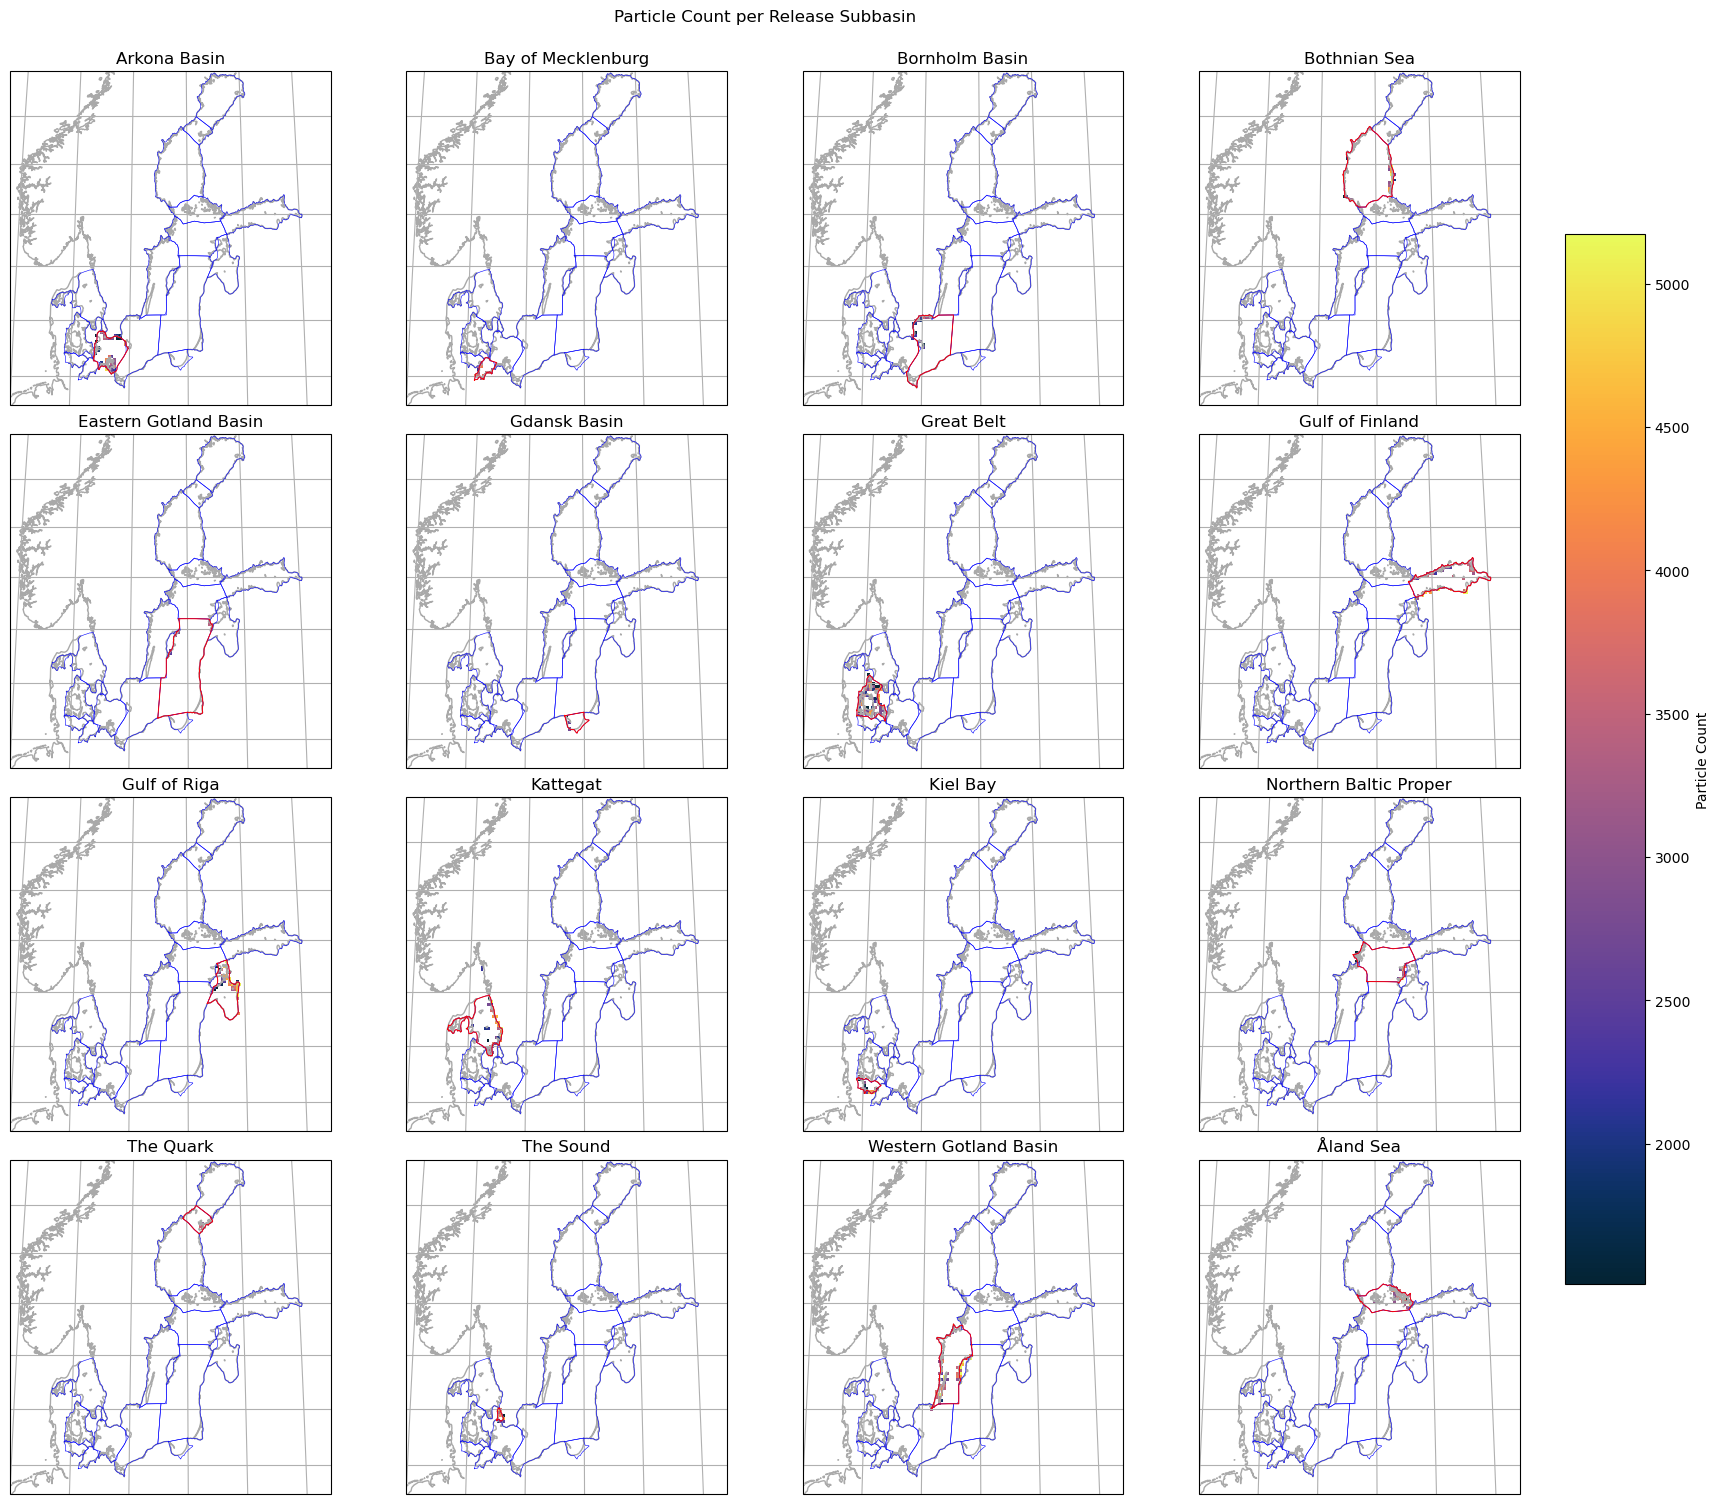

In [145]:
ds_plot = ds_plot_traj_0_count.sum(dim="obs")

vmin, vmax = list(ds_plot.where(ds_plot.notnull() & ~np.isinf(ds_plot)).quantile([0.05, 0.95]))

fig, axes = plt.subplots(
        figsize=(16, 15),
        nrows=4, ncols=4, 
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)

fig.suptitle("Particle Count per Release Subbasin", y=1)
for ax, basin in zip(axes.flatten(), ds_plot.subbasin.values):
        subbasins_simple.plot(ax=ax, transform=ccrs.Geodetic(), color="b", lw=.4, zorder=10,)
        ax.plot(*subbasins_simple.loc[basin].xy, transform=ccrs.PlateCarree(), color="r", lw=.7, zorder=30,)
        im = ds_plot.sel(subbasin=basin).plot.pcolormesh(
                x="lon", y="lat", ax=ax, 
                vmin=vmin, vmax=vmax, 
                cmap=cmocean.cm.thermal,
                add_colorbar=False, transform=ccrs.PlateCarree(),
        )
        ax.set_title(basin)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent((lon_min, lon_max, lat_min, lat_max))

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Particle Count")
fig.tight_layout()
plt.show()

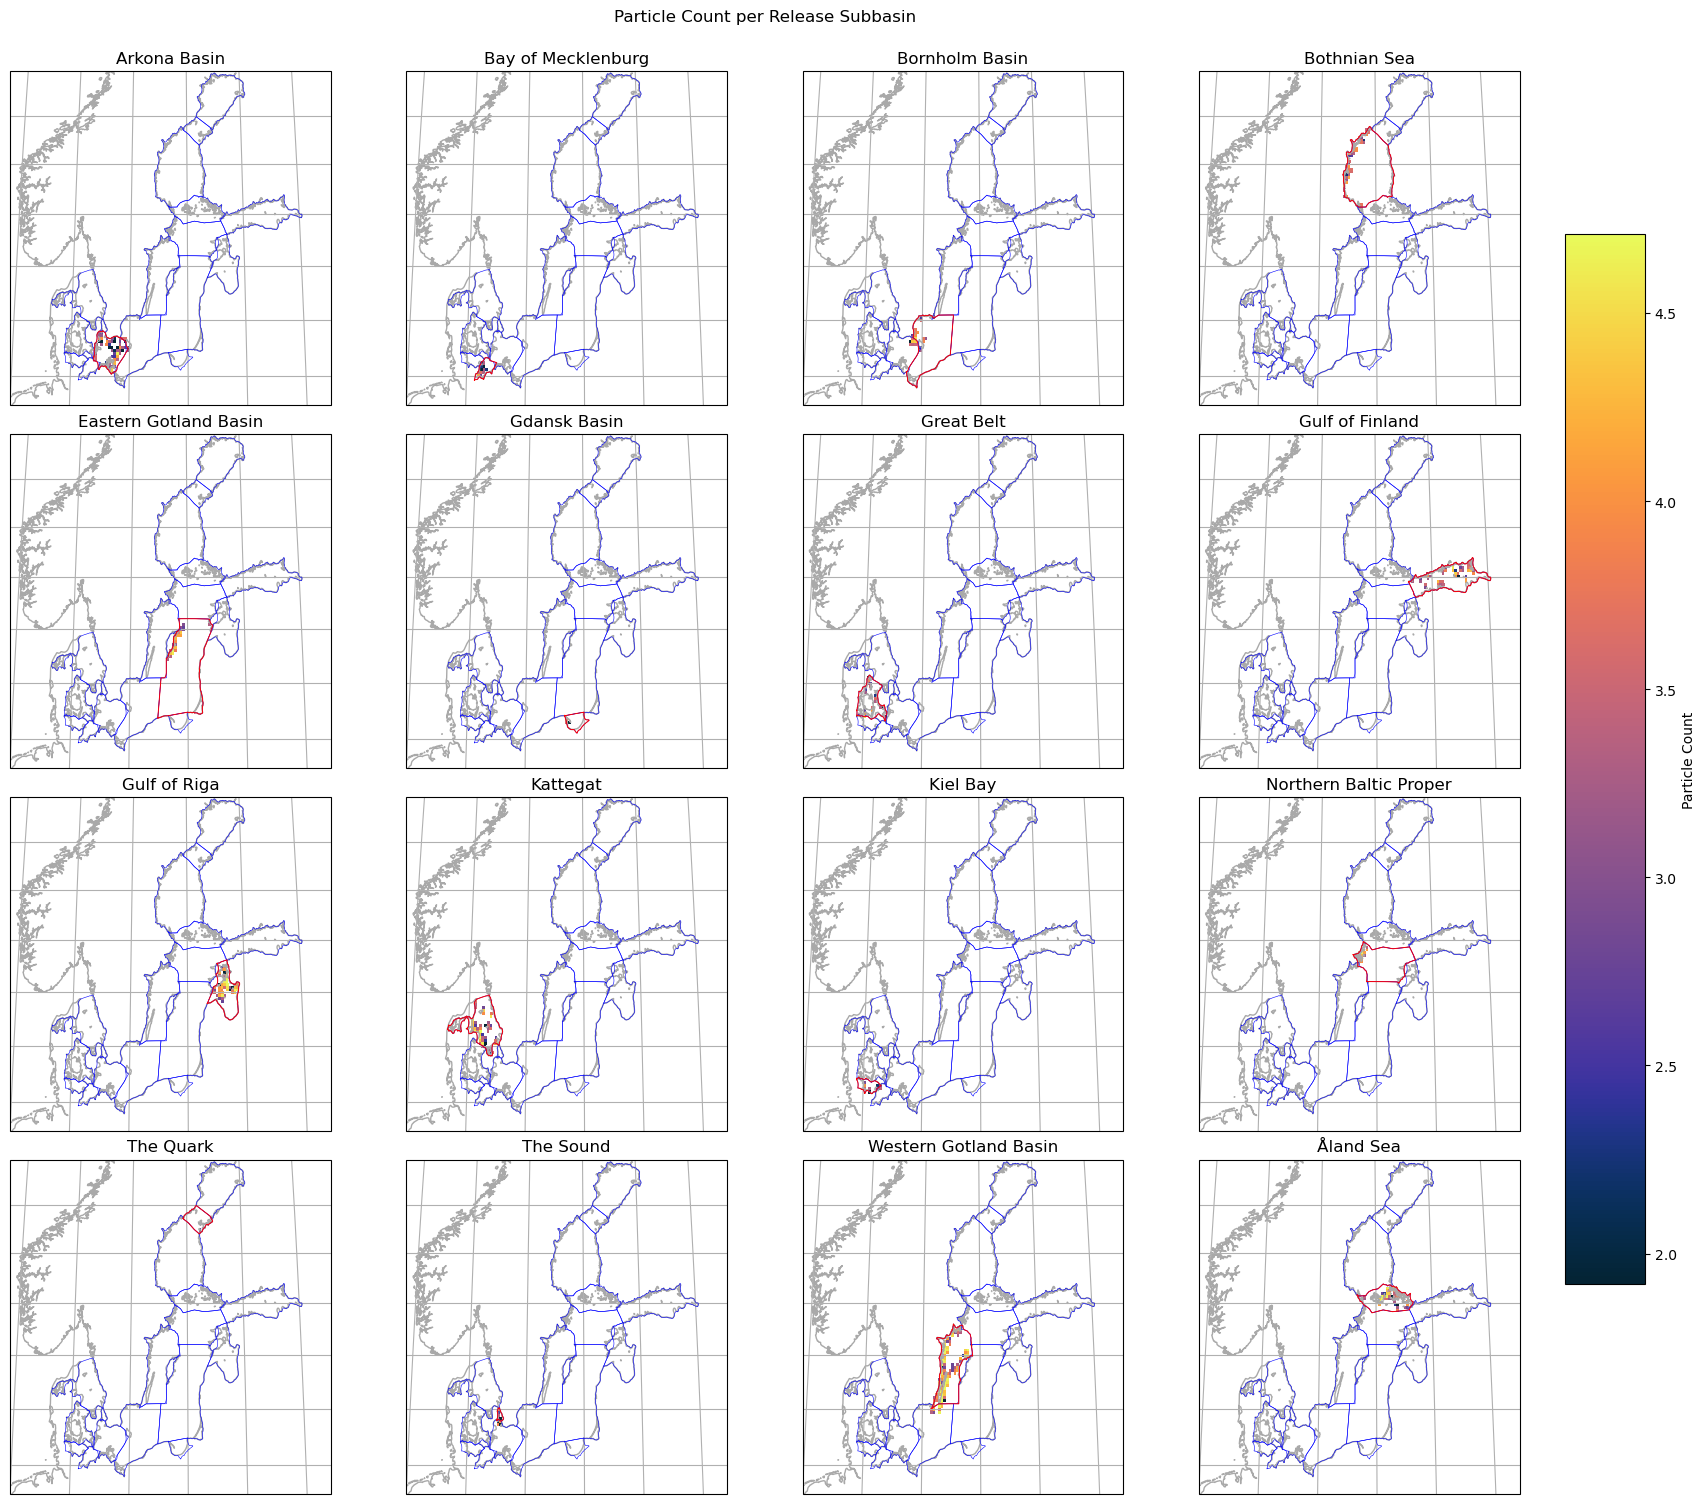

In [113]:
ds_plot = ds_plot_traj_1_count

vmin, vmax = list(ds_plot.where(ds_plot.notnull() & ~np.isinf(ds_plot)).quantile([0.05, 0.95]))

fig, axes = plt.subplots(
        figsize=(16, 15),
        nrows=4, ncols=4, 
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)

fig.suptitle("Particle Count per Release Subbasin", y=1)
for ax, basin in zip(axes.flatten(), ds_plot.subbasin.values):
        subbasins_simple.plot(ax=ax, transform=ccrs.Geodetic(), color="b", lw=.4, zorder=10,)
        ax.plot(*subbasins_simple.loc[basin].xy, transform=ccrs.PlateCarree(), color="r", lw=.7, zorder=30,)
        im = ds_plot.sel(subbasin=basin).plot.pcolormesh(
                x="lon", y="lat", ax=ax, 
                vmin=vmin, vmax=vmax, 
                cmap=cmocean.cm.thermal,
                add_colorbar=False, transform=ccrs.PlateCarree(),
        )
        ax.set_title(basin)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent((lon_min, lon_max, lat_min, lat_max))

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Particle Count")
fig.tight_layout()
plt.show()

## Agemap

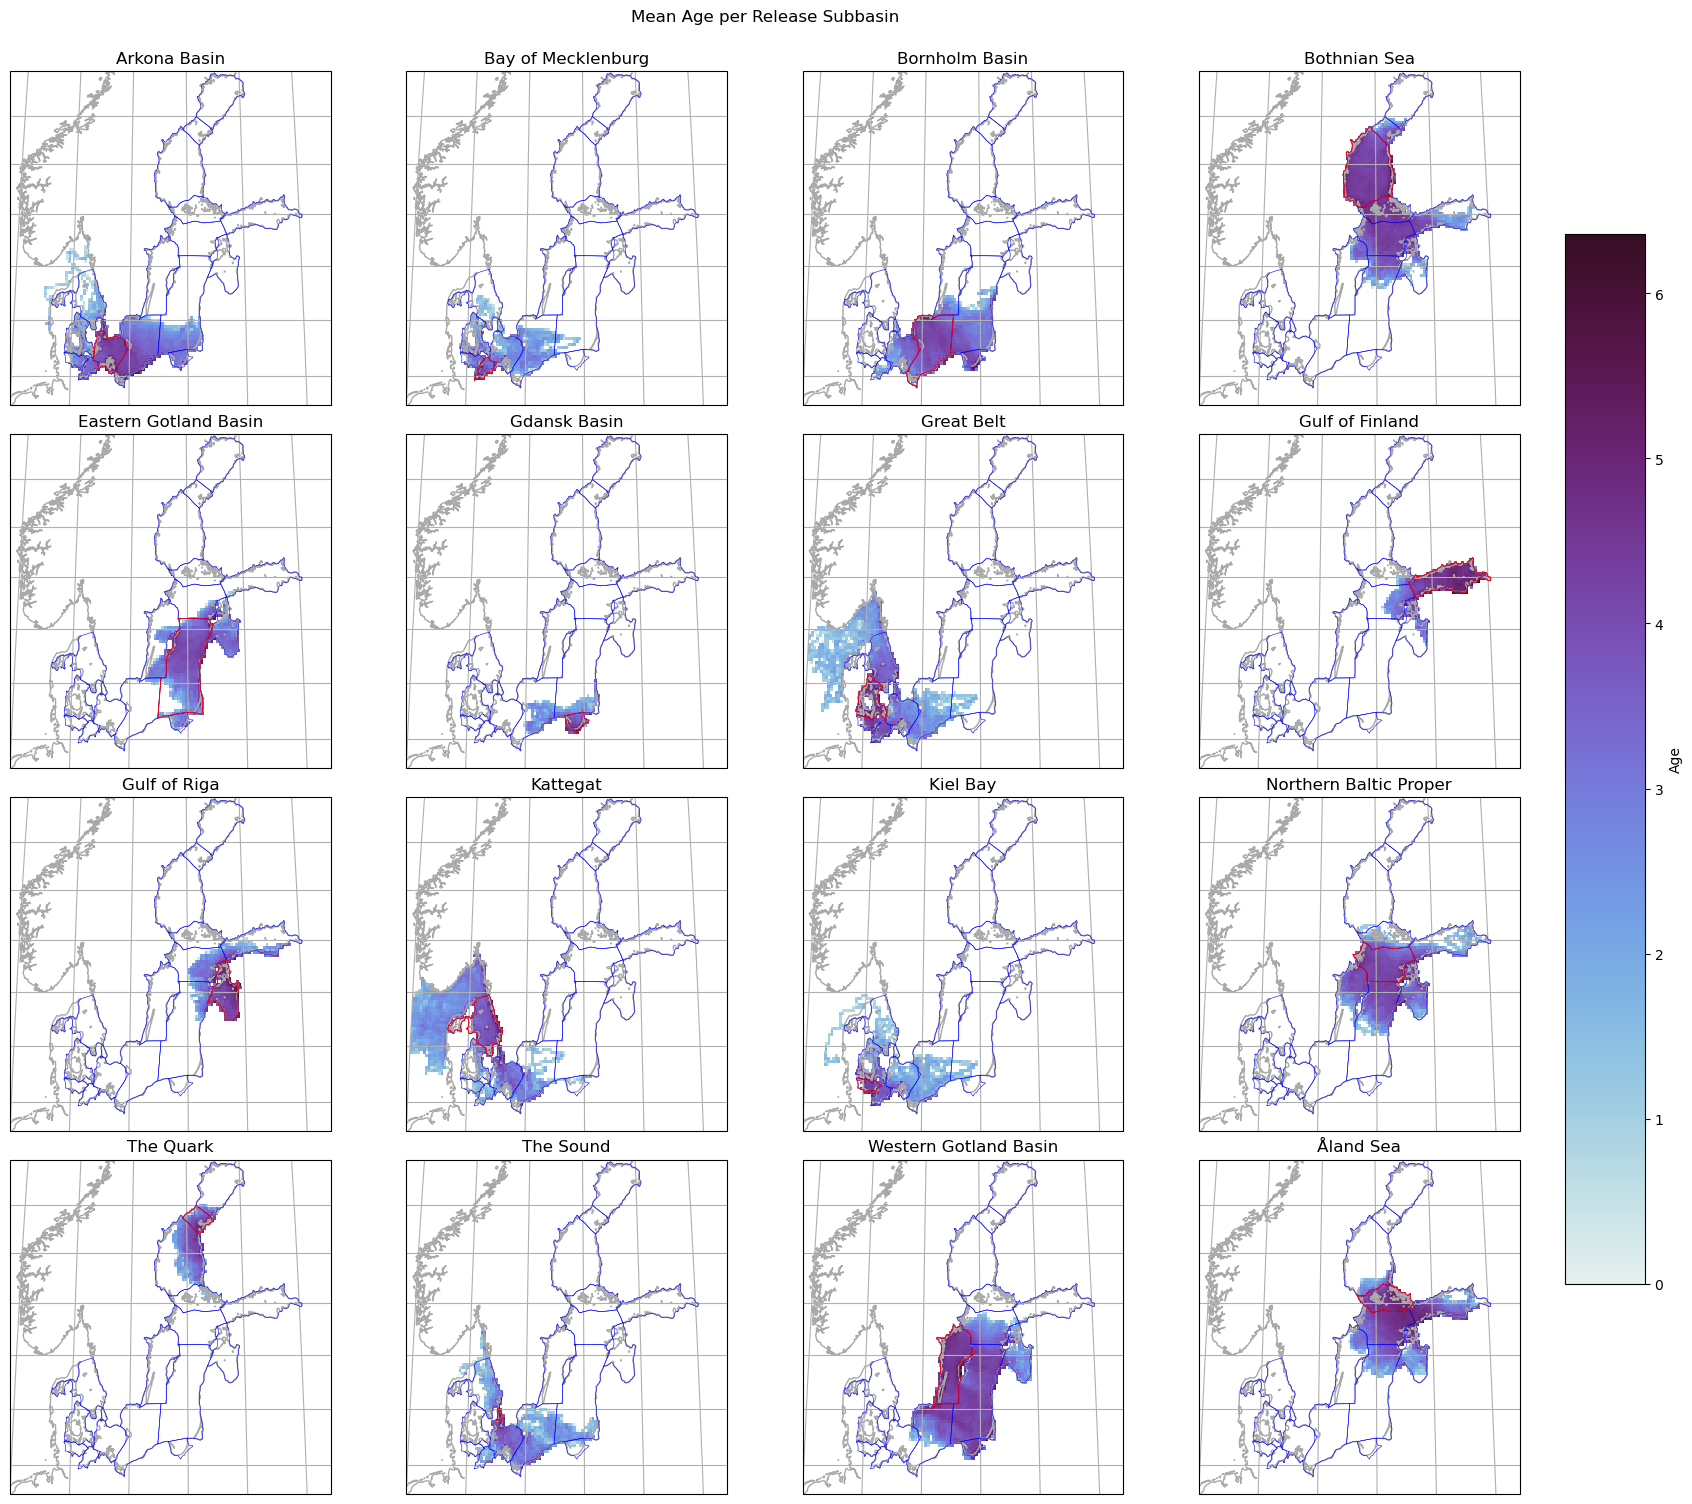

In [125]:
ds_plot = ds_plot_traj_0_count
vmin = 0
vmax = ds_plot.max()
fig, axes = plt.subplots(
        figsize=(16, 15),
        nrows=4, ncols=4, 
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)

fig.suptitle("Mean Age per Release Subbasin", y=1)
for ax, basin in zip(axes.flatten(), ds_plot.subbasin.values):
        subbasins_simple.plot(ax=ax, transform=ccrs.Geodetic(), color="b", lw=.4, zorder=10,)
        ax.plot(*subbasins_simple.loc[basin].xy, transform=ccrs.PlateCarree(), color="r", lw=.7, zorder=30,)
        im = ds_plot.sel(subbasin=basin).plot.pcolormesh(
                x="lon", y="lat", ax=ax, 
                cmap=cmocean.cm.dense,
                vmin=vmin, vmax=vmax, 
                add_colorbar=False, transform=ccrs.PlateCarree(),
        )
        ax.set_title(basin)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent((lon_min, lon_max, lat_min, lat_max))

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Age")
fig.tight_layout()
plt.show()

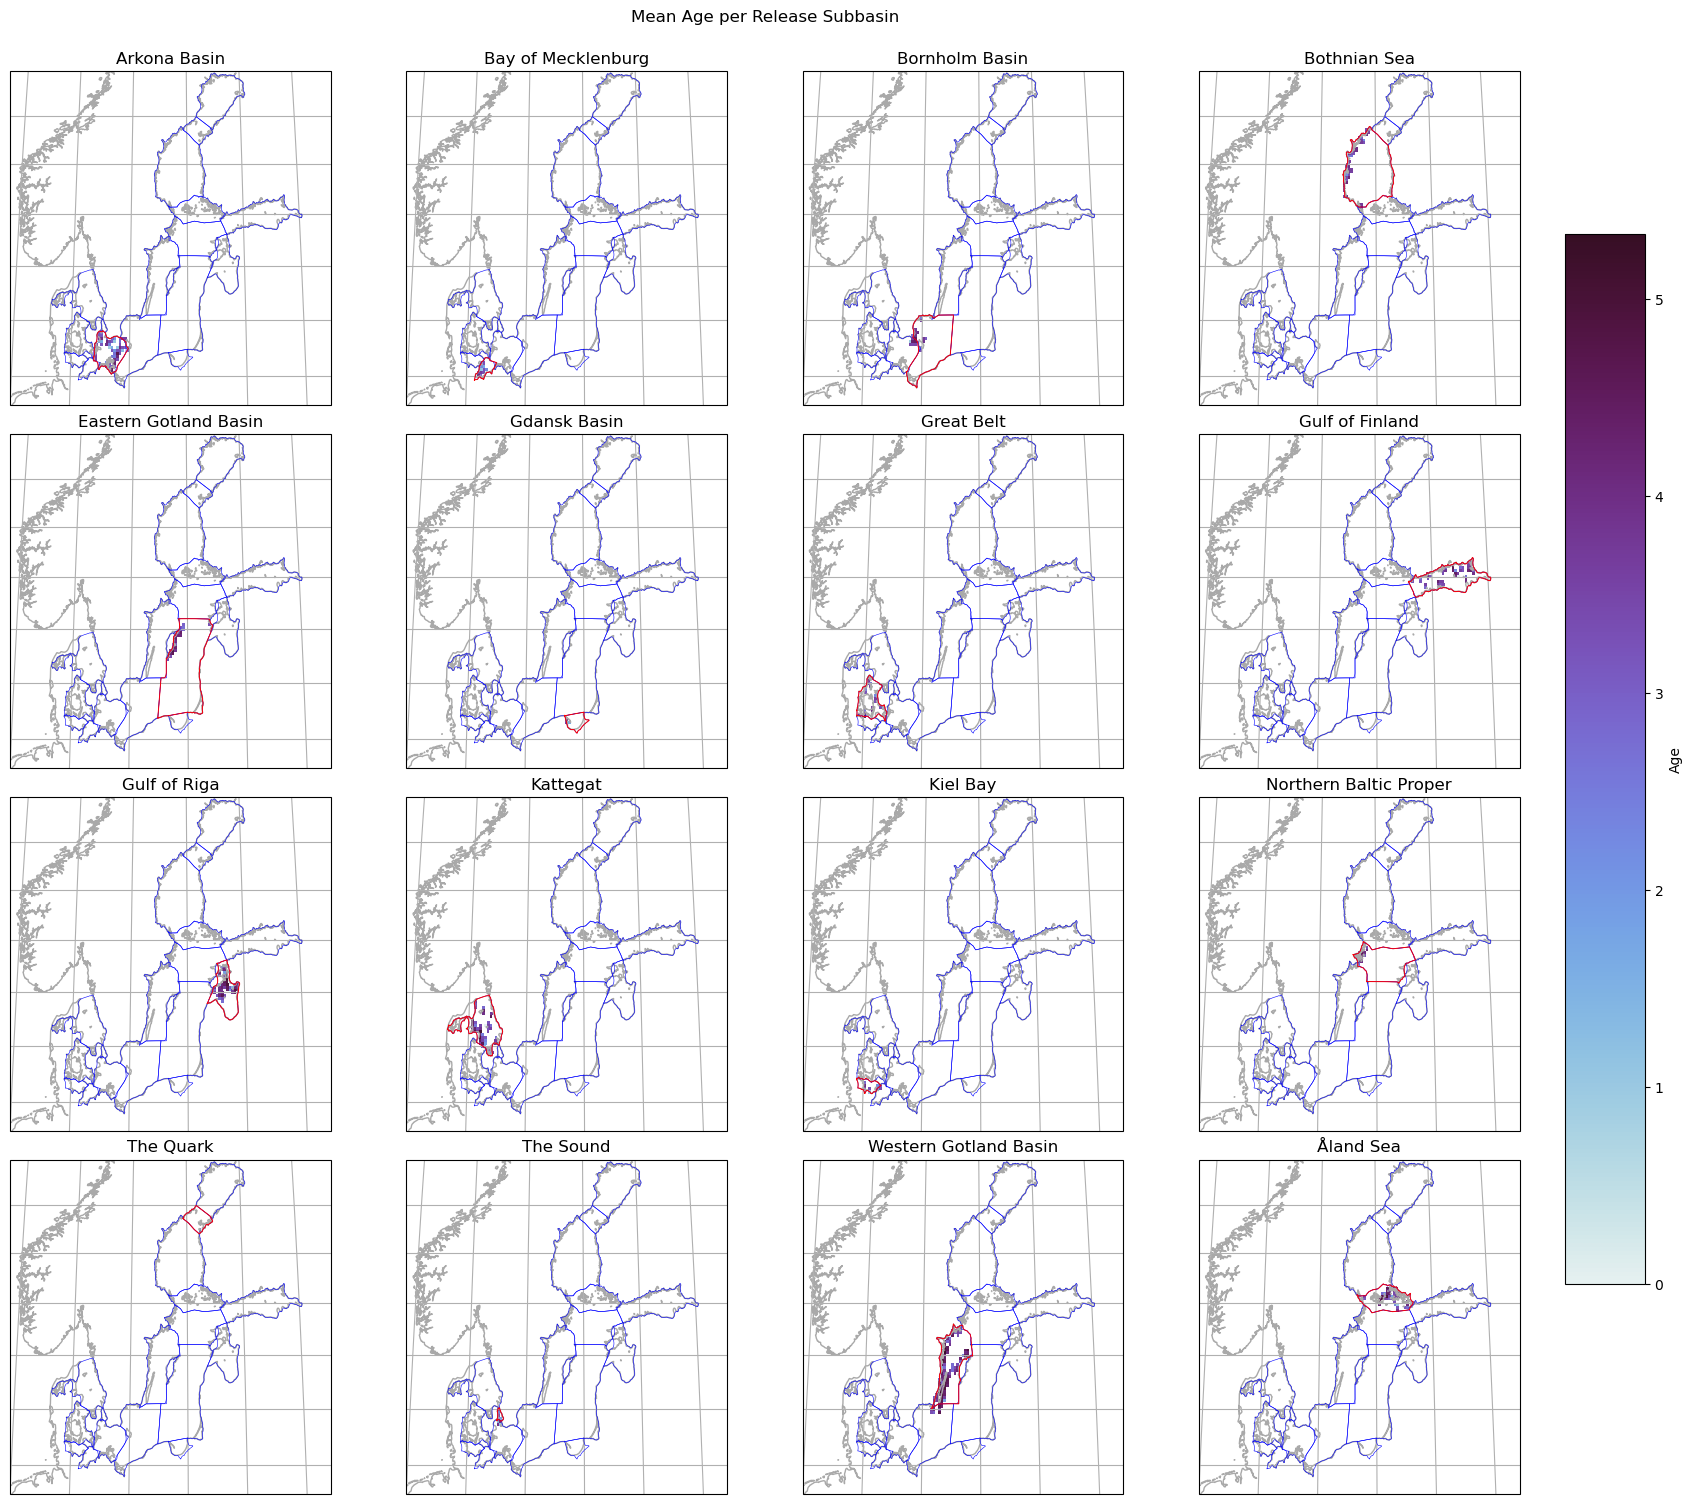

In [ ]:
ds_plot = ds_plot_traj_1_count
vmin = 0
vmax = ds_plot.max()
fig, axes = plt.subplots(
        figsize=(16, 15),
        nrows=4, ncols=4, 
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)

fig.suptitle("Mean Age per Release Subbasin", y=1)
for ax, basin in zip(axes.flatten(), ds_plot.subbasin.values):
        subbasins_simple.plot(ax=ax, transform=ccrs.Geodetic(), color="b", lw=.4, zorder=10,)
        ax.plot(*subbasins_simple.loc[basin].xy, transform=ccrs.PlateCarree(), color="r", lw=.7, zorder=30,)
        im = ds_plot.sel(subbasin=basin).plot.pcolormesh(
                x="lon", y="lat", ax=ax, 
                cmap=cmocean.cm.dense,
                vmin=vmin, vmax=vmax, 
                add_colorbar=False, transform=ccrs.PlateCarree(),
        )
        ax.set_title(basin)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent((lon_min, lon_max, lat_min, lat_max))

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Age")
fig.tight_layout()
plt.show()

# Regional Kiel Bay Plots

In [24]:
ds_kiel = ds_trajectories.where(ds_trajectories.subbasin=="Kiel Bay", drop=True)[["lon", "lat"]].compute()
ds_kiel

<xarray.Dataset> Size: 333MB
Dimensions:     (trajectory: 3928, obs: 5304)
Coordinates:
  * obs         (obs) int32 21kB 0 1 2 3 4 5 6 ... 5298 5299 5300 5301 5302 5303
  * trajectory  (trajectory) int64 31kB 1 38 58 89 ... 235246 235325 235416
Data variables:
    lon         (trajectory, obs) float64 167MB 10.95 10.96 10.96 ... nan nan
    lat         (trajectory, obs) float64 167MB 54.41 54.42 54.42 ... nan nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_SIGMABSHaging_kernel
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [25]:
kiel_lon_min, kiel_lon_max = ds_kiel.lon.min().values, ds_kiel.lon.max().values
kiel_lat_min, kiel_lat_max = ds_kiel.lat.min().values, ds_kiel.lat.max().values

In [26]:
n_bins = 120
ds_plot_kiel_0 = np.log10(
        calc_hist_0(
                ds_kiel,
                np.linspace(kiel_lon_min, kiel_lon_max, n_bins),
                np.linspace(kiel_lat_min, kiel_lat_max, n_bins),
                dims=[
                        "trajectory", 
                        # "obs"
                ],
        )
).compute()
ds_plot_kiel_0

<xarray.DataArray 'histogram_lon_lat' (obs: 5304, lon: 119, lat: 119)> Size: 601MB
array([[[-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        ...,
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf]],

       [[-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        ...,
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf]],

       [[-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        ...,
...
        ...,
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf]],

       [[-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        ...,
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf]],

       [[-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        ...,
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf]]])
Coordinates:
  * obs      (obs) int32 21kB 0 1 2 3 4 5 6 ... 5298 5299 5300 5301 5302 5303
  * lon      (lon) float64 952B 9.487 9.599 9.712 9.824 ... 22.54 22.65 22.77
  * lat      (lat) float64 952B 53.94 53.98 54.02 54.06 ... 58.39 58.43 58.47

## Animations

In [126]:
import matplotlib.animation as animation

In [149]:
max_age = timedelta(seconds=int(last_step.age_sec.max()))
max_age_days = int(np.ceil(max_age.days))

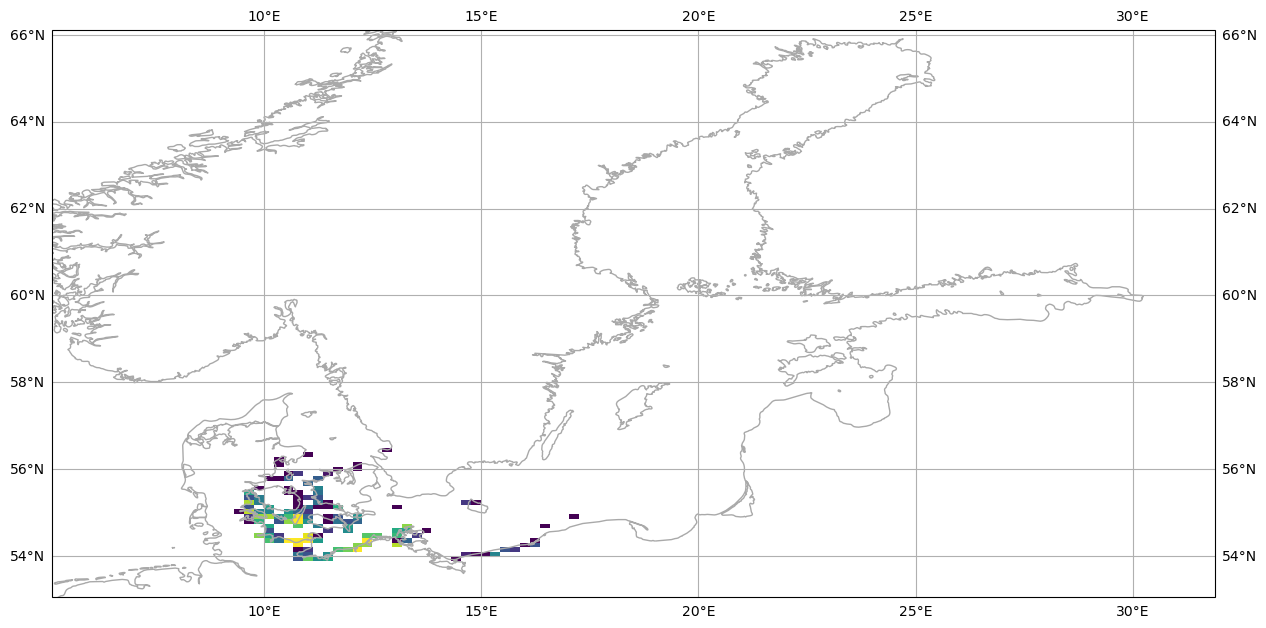

In [154]:
ds_ani = ds_plot_traj_0_count.sel(subbasin="Kiel Bay").groupby_bins(group="obs", bins=max_age_days).mean(dim="obs")

vmin, vmax = list(ds_ani.where(ds_ani.notnull() & ~np.isinf(ds_ani)).quantile([0.05, 0.95]))
fig, ax = plt.subplots(
        figsize=(15,15),
        subplot_kw=dict(projection=ccrs.PlateCarree()), 
)
heat = ax.pcolormesh(
        ds_ani.lon, ds_ani.lat,
        ds_ani.isel(obs_bins=0).T,
        vmin=vmin, vmax=vmax, 
        transform=ccrs.PlateCarree(),
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
ax.set_extent((ds_ani.lon.min(), ds_ani.lon.max(), ds_ani.lat.min(), ds_ani.lat.max()))
def animate(i):
        heat.set_array(ds_ani.isel(obs_bins=i).values.T.flatten())

ani = animation.FuncAnimation(
        fig, animate, 
        interval=100, frames=len(ds_ani.obs_bins)
)
ani.save(
        filename="/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/output/kiel_bay_heatmap.gif", 
        writer="pillow")
plt.show()

In [159]:
ds_traj_0.where(ds_traj_0.subbasin == "Kiel Bay", drop=True)

<xarray.Dataset> Size: 234MB
Dimensions:     (trajectory: 2310, obs: 2112)
Coordinates:
  * obs         (obs) int32 8kB 0 1 2 3 4 5 6 ... 2106 2107 2108 2109 2110 2111
  * trajectory  (trajectory) int64 18kB 46 244 346 492 ... 453062 453236 453268
Data variables:
    age_sec     (trajectory, obs) float32 20MB dask.array<chunksize=(2310, 24), meta=np.ndarray>
    cell_ID     (trajectory, obs) float32 20MB dask.array<chunksize=(2310, 24), meta=np.ndarray>
    lat         (trajectory, obs) float64 39MB dask.array<chunksize=(2310, 24), meta=np.ndarray>
    lon         (trajectory, obs) float64 39MB dask.array<chunksize=(2310, 24), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 39MB dask.array<chunksize=(2310, 24), meta=np.ndarray>
    z           (trajectory, obs) float64 39MB dask.array<chunksize=(2310, 24), meta=np.ndarray>
    distance    (trajectory, obs) float64 39MB dask.array<chunksize=(2310, 24), meta=np.ndarray>
    subbasin    (trajectory) object 18kB 'Kiel Bay' 'Kiel Bay' ... 'Kiel Bay'
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_SIGMABSHaging_kernel
    parcels_mesh:           spherical
    parcels_version:        3.0.6

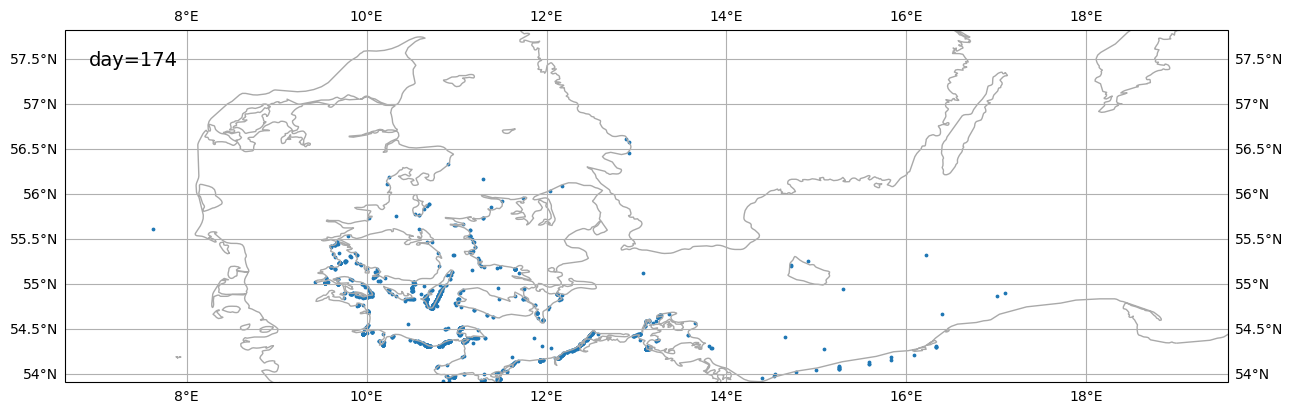

In [171]:
ds_scatter_ani = (
        ds_traj_0
        .where(ds_traj_0.subbasin == "Kiel Bay", drop=True)
        .groupby_bins(group="obs", bins=max_age_days*2)
        .mean(dim="obs")
        # .isel(trajectory=slice(5))
)

fig, ax = plt.subplots(
        figsize=(15,15),
        subplot_kw=dict(projection=ccrs.PlateCarree()), 
)

# x_initial = ds_scatter_ani.lon.T
# y_initial = ds_scatter_ani.lat.T

# lines = [ax.plot(x, y, color="lightgrey", linewidth=1.4)[0] for x, y in zip(x_initial, y_initial)]

scat = ax.scatter(
        ds_scatter_ani.isel(obs_bins=0).lon.T,
        ds_scatter_ani.isel(obs_bins=0).lat.T,
        s=3, transform=ccrs.PlateCarree(),
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
ax.set_extent((ds_scatter_ani.lon.min(), ds_scatter_ani.lon.max(), ds_scatter_ani.lat.min(), ds_scatter_ani.lat.max()))
time_text = ax.text(0.02,0.9,"day=1", transform=ax.transAxes, size=14,)

def animate(frame):
        time_text.set_text(f"day={(int(frame+1))}")
        x = ds_scatter_ani.isel(obs_bins=frame).lon.values
        y = ds_scatter_ani.isel(obs_bins=frame).lat.values
        data = np.stack([x,y]).T
        scat.set_offsets(data)
        # for i, line in enumerate(lines):
        #         x_update = x_initial[i][:frame+1]
        #         y_update = y_initial[i][:frame+1]
        #         line.set_xdata(x_update)
        #         line.set_ydata(y_update)
        # return lines

ani = animation.FuncAnimation(fig, func=animate, interval=100, frames=len(ds_scatter_ani.obs_bins))
ani.save(
        filename="/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/output/kiel_bay_scatter.gif", 
        writer="pillow")
plt.show()

# Coastbuffer
Make coast buffer for check if near coast or in open water

In [22]:
gdf_baltic = gdf_subbasins_area.dissolve()
coast_region_radius_km = 25
coast_region_radius = coast_region_radius_km / earth_radius * radians_to_degrees
gdf_baltic_simple = gdf_baltic.buffer(.1).buffer(-.1)
# gdf_baltic_benthic = gdf_baltic_simple.buffer(-coast_region_radius)
# gdf_baltic_coast = gdf_baltic_buffed.difference(gdf_baltic_benthic)
# gdf_baltic_coast

In [ ]:
gdf_baltic_coast = gdf_baltic_simple.boundary.buffer(.2)

<Axes: >

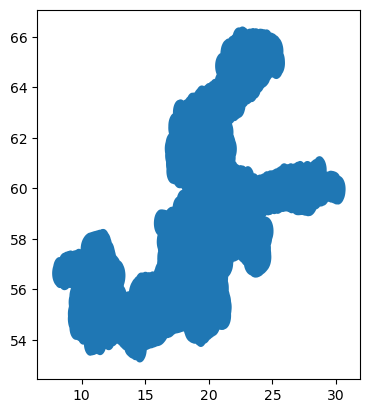

In [155]:
gdf_baltic_simple.buffer(.5).plot()

<Axes: >

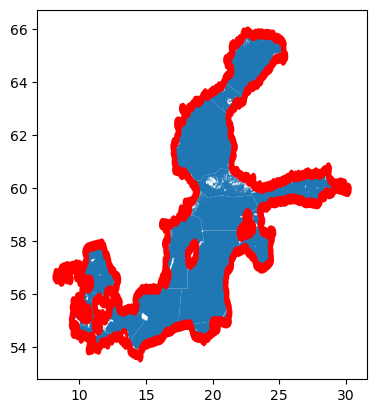

In [24]:
fig, ax = plt.subplots()
gdf_subbasins_area.plot(ax=ax)
gdf_baltic_coast.plot(ax=ax, color="r")

<Axes: >

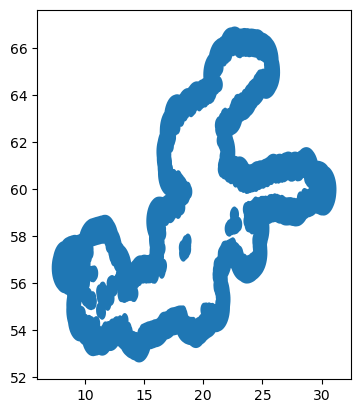

In [185]:
gdf_baltic_coast_extended = gdf_baltic_simple.buffer(1).difference(gdf_baltic_simple).union(gdf_baltic_coast)
gdf_baltic_coast_extended.plot()

In [187]:
df_first_step = ds_traj_0.isel(obs=0)[["lon", "lat"]].drop("obs").to_dataframe()
gdf_first_step = gpd.GeoDataFrame(
        dict(
                trajectory=ds_traj_0.isel(obs=0).trajectory,
                geometry=gpd.points_from_xy(df_first_step.lon, df_first_step.lat),
        ),
        crs=gdf_baltic_coast.crs,
)
gdf_first_step = gdf_first_step.loc[:10000]

In [188]:
gdf_first_step["near_coast"] = gdf_first_step.within(gdf_baltic_coast_extended.unary_union)

gdf_first_step = gpd.sjoin_nearest(
        left_df=gdf_first_step,
        right_df=gdf_subbasins_area,
        how="left", 
        rsuffix="basin_",
)[["trajectory", "geometry", "near_coast", "subbasin"]]

In [189]:
df_last_step = last_step[["lon", "lat"]].drop("obs").to_dataframe()
gdf_last_step = gpd.GeoDataFrame(
        dict(
                trajectory=last_step.trajectory,
                geometry=gpd.points_from_xy(df_last_step.lon, df_last_step.lat),
        ),
        crs=gdf_baltic_coast.crs,
)
gdf_last_step = gdf_last_step.loc[:10000]

<Axes: >

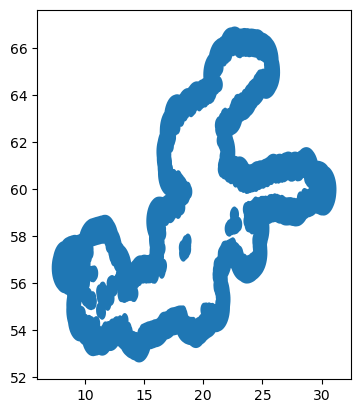

In [200]:
gdf_baltic_coast_extended.plot()

In [190]:
gdf_last_step["near_coast"] = gdf_last_step.within(gdf_baltic_coast_extended.unary_union)
gdf_last_step = gdf_last_step.sjoin_nearest(
        right=gdf_subbasins_area,
        how="left", 
        rsuffix="basin_",
)[["trajectory", "geometry", "near_coast", "subbasin"]]

In [ ]:
gdf_joined = gdf_first_step.join(gdf_last_step, on="trajectory", how="right", lsuffix="_first", rsuffix="_last")

In [ ]:
gdf_joined["stayed_in_basin"] = (gdf_joined.subbasin_last == gdf_joined.subbasin_first)
gdf_joined["stayed_near_coast"] = (gdf_joined.near_coast_last & gdf_joined.near_coast_first) == True
gdf_joined["stayed_local"] = gdf_joined.stayed_in_basin & gdf_joined.stayed_near_coast

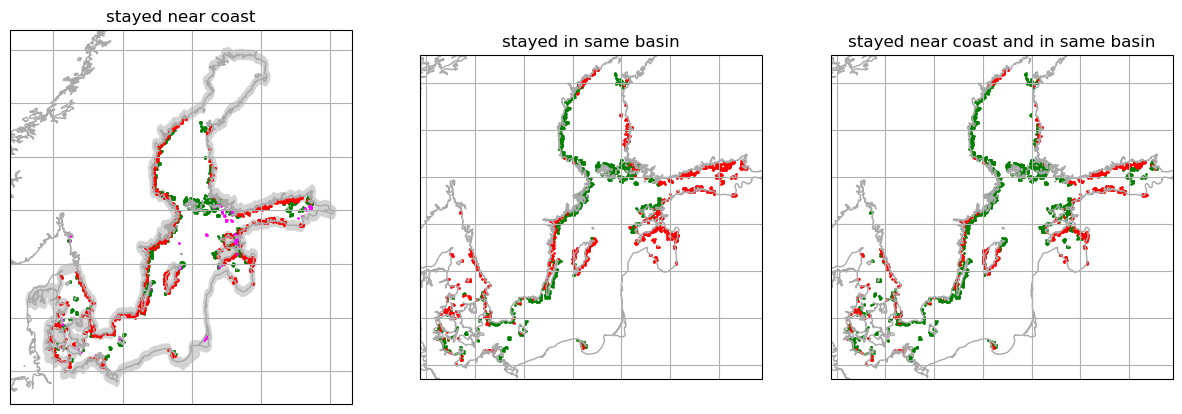

In [201]:
fig, axes = plt.subplots(figsize=(15,5), ncols=3, subplot_kw=dict(projection=ccrs.PlateCarree()))
axes = axes.flatten()
gdf_baltic_coast.plot(ax=axes[0], color="lightgrey")
gdf_joined.where(gdf_joined.stayed_near_coast != True).dropna().geometry_first.plot(ax=axes[0], markersize=1, color="g")
gdf_joined.where(gdf_joined.stayed_near_coast == True).dropna().geometry_first.plot(ax=axes[0], markersize=1, color="r")
gdf_joined.where(gdf_joined.near_coast_last != True).dropna().geometry_last.plot(ax=axes[0], markersize=1, color="magenta")
axes[0].set_title("stayed near coast")
gdf_joined.where(gdf_joined.stayed_in_basin != True).dropna().geometry_first.plot(ax=axes[1], markersize=1, color="g")
gdf_joined.where(gdf_joined.stayed_in_basin == True).dropna().geometry_first.plot(ax=axes[1], markersize=1, color="r")
axes[1].set_title("stayed in same basin")
gdf_joined.where(gdf_joined.stayed_local != True).dropna().geometry_first.plot(ax=axes[2], markersize=1, color="g")
gdf_joined.where(gdf_joined.stayed_local == True).dropna().geometry_first.plot(ax=axes[2], markersize=1, color="r")
axes[2].set_title("stayed near coast and in same basin")
for ax in axes:
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
plt.show()

In [ ]:
gdf_first_step["near_coast"] = gdf_first_step.within(gdf_baltic_coast.unary_union)

gdf_first_step = gpd.sjoin_nearest(
        left_df=gdf_first_step,
        right_df=gdf_subbasins_area,
        how="left", 
        rsuffix="basin_",
)[["trajectory", "geometry", "near_coast", "subbasin"]]

statistics of in which month and from which starting position do the particles travel how far, and the area

In [10]:
def calc_dist_quantiles(ds):
        dist = 111e3 * (
                ((ds[["lon", "lat"]] - ds.isel(obs=0, drop=True)[["lon", "lat"]]) ** 2).to_array() 
                * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
        ).sum(dim="variable")**0.5
        return dist.where(ds.lon.notnull()).quantile(np.linspace(0,1,5), dim="trajectory").rename("dist")

In [ ]:
def calc_dist_mean(ds):
        dist = 111e3 * (
                ((ds[["lon", "lat"]] - ds.isel(obs=0, drop=True)[["lon", "lat"]]) ** 2).to_array() 
                * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
        ).sum(dim="variable")**0.5
        return dist.where(ds.lon.notnull()).mean(dim="trajectory").rename("dist")

In [12]:
df_distance_q = ds_trajectories.groupby("subbasin").apply(calc_dist_quantiles).compute().to_dataframe()

KeyError: "No variable named 'subbasin'. Variables on the dataset include ['age_sec', 'cell_ID', 'lat', 'lon', 'obs', 'time', 'trajectory', 'z']"

In [ ]:
# df_distance_q.unstack(0).loc[0.5].assign(time=np.timedelta64(1, "h")*np.arange(5304)).set_index("time", drop=True).resample("5D").max()["dist"].plot()


In [ ]:
ds_traj_0.age_sec.isel(trajectory=0).compute().astype('timedelta64[s]')

<xarray.DataArray 'age_sec' (obs: 2112)> Size: 17kB
array([    900000000000,    4500000000000,    8100000000000, ...,
       7593300000000000, 7596900000000000, 7600500000000000],
      dtype='timedelta64[ns]')
Coordinates:
  * obs         (obs) int32 8kB 0 1 2 3 4 5 6 ... 2106 2107 2108 2109 2110 2111
    trajectory  int64 8B 2
Attributes:
    long_name:      
    standard_name:  age_sec
    units:          unknown

In [251]:
df_traj_0 = ds_traj_0.groupby("subbasin").mean().distance.to_dataframe().unstack(0)
df_traj_0 = df_traj_0.assign(time=ds_traj_0.age_sec.isel(trajectory=0).compute().astype('timedelta64[s]')).set_index("time", drop=True)
df_traj_0_5d = df_traj_0.resample("5D").mean()

In [48]:
df_distance_m = ds_trajectories.groupby("subbasin").apply(calc_dist_mean).compute().to_dataframe()
df_distance_m = df_distance_m.unstack(0).assign(time=np.timedelta64(1, "h")*np.arange(5304)).set_index("time", drop=True).resample("5D").mean()["dist"]

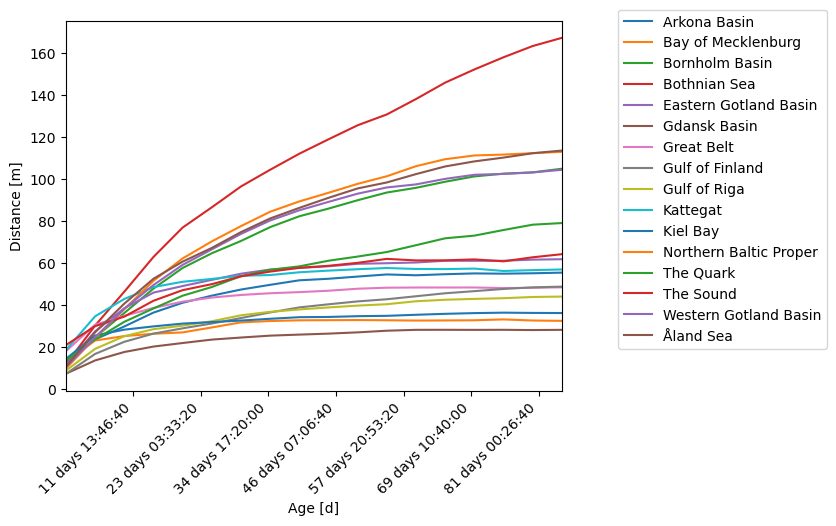

In [252]:
# fig, ax = plt.subplots(111, figsize=(15,10))
p = df_traj_0_5d.distance.plot()
p.legend(loc="best", bbox_to_anchor=(1.1, 1.05))
# p.tick_params("x", rotation=45,)
plt.xticks(rotation=45, ha="right")
# a =print(p.xaxis.get_ticklabels())
# print(p.xaxis.get_majorticklocs())
# p.xaxis.set_major_formatter()
# p.set_xticklabels(labels=np.timedelta64(1, "D")*np.arange(0, 220, 7))
p.set_xlabel("Age [d]")
p.set_ylabel("Distance [m]")
plt.show()

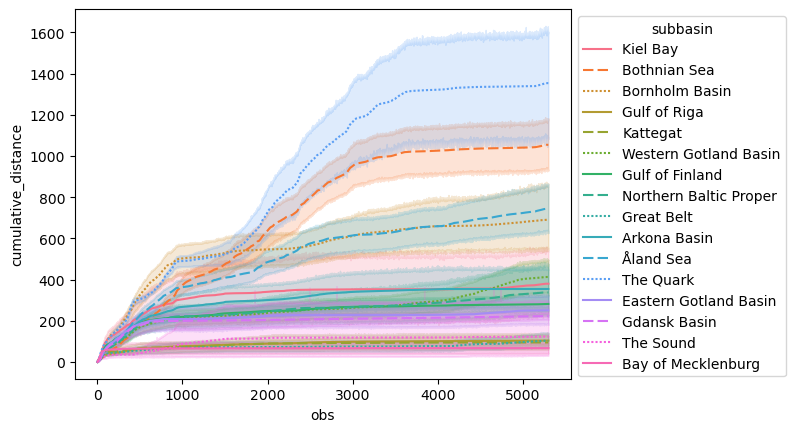

In [ ]:
fig = plt.Figure((15,15))
ax = sns.lineplot(
        data=df, 
        x="obs", y="cumulative_distance",
        hue="subbasin",
        style="subbasin",
        dashes=['', (5, 2), (1, 1)],
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

In [323]:
df_traj_0_last = ds_traj_0.isel(obs=-1)[["subbasin", "distance"]].to_dataframe()
df_traj_0_last = df_traj_0_last.reset_index().set_index(["subbasin", "trajectory"]).sort_index()[["distance"]]
df_traj_0_last

distance
subbasin     trajectory            
Arkona Basin 68           18.813938
             172         137.112805
             232          19.712786
             268          82.302268
             334          93.347239
...                             ...
Åland Sea    453346             NaN
             453362             NaN
             453414             NaN
             453432             NaN
             453434             NaN

[118835 rows x 1 columns]

<Axes: xlabel='distance', ylabel='subbasin'>

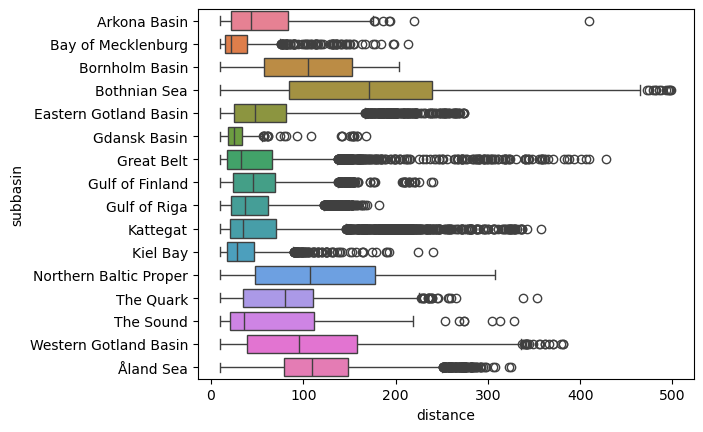

In [327]:
sns.boxplot(df_traj_0_last, x="distance", y="subbasin", hue="subbasin")

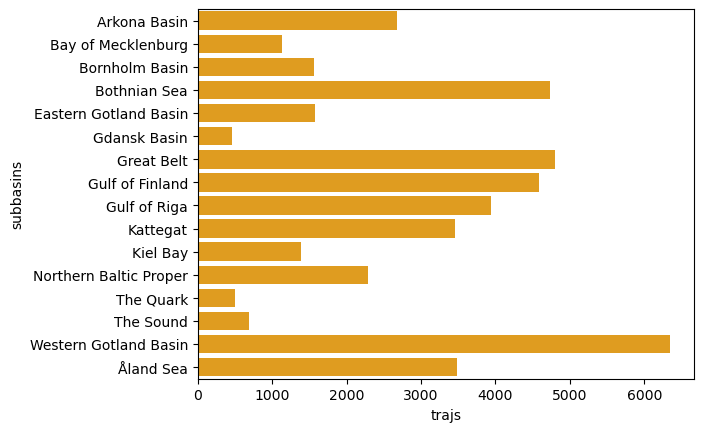

<Axes: xlabel='cells', ylabel='subbasins'>

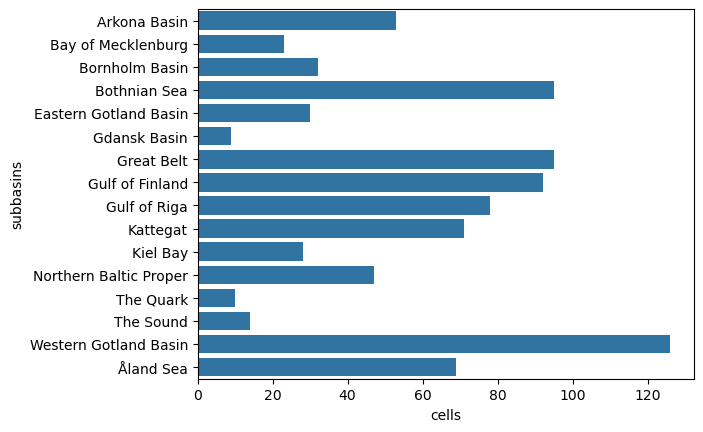

In [61]:
sns.barplot(basins, x="trajs", y="subbasins", color="orange")
plt.show()
sns.barplot(basins, x="cells", y="subbasins")